# RANDOM FORES PARA DETERMINAR DIABETES
# FUENTE [KAGGLE](https://www.kaggle.com/datasets/kumargh/pimaindiansdiabetescsv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumargh/pimaindiansdiabetescsv")

print("Path to dataset files:", path)

100%|██████████| 8.89k/8.89k [00:00<00:00, 9.49MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumargh/pimaindiansdiabetescsv/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/kumargh/pimaindiansdiabetescsv/versions/1

pima-indians-diabetes.csv


In [4]:
PATH_CSV = path + '/pima-indians-diabetes.csv'

In [6]:
df_diabetes = pd.read_csv(PATH_CSV,header=None)
df_diabetes.head(10)

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [7]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Class']
df_diabetes.columns = columns
df_diabetes.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [8]:
df_diabetes.isna().sum().sum()

np.int64(0)

# ENTRENAMIENTO DE MODELO

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [10]:
X = df_diabetes.drop(columns=['Class'])

In [11]:
y = df_diabetes['Class']

In [12]:
df_diabetes.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Class,int64


In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': np.arange(2, 20, 2),
    'min_samples_leaf': np.arange(1, 10, 2),
    'max_features': ['sqrt', 'log2']
}

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

grid_search = RandomizedSearchCV(estimator=rf,param_distributions=param_dist,
                                 n_iter=20,cv=5,scoring='accuracy',
                                 n_jobs=-1,verbose=2)

grid_search.fit(X_train,y_train)

print('mejores parametros : ',grid_search.best_params_)
print('mejor puntuación : ',grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
mejores parametros :  {'n_estimators': np.int64(100), 'min_samples_split': np.int64(16), 'min_samples_leaf': np.int64(1), 'max_features': 'sqrt', 'max_depth': 20}
mejor puntuación :  0.7834199653471945


In [15]:
model = RandomForestClassifier(random_state=42, **grid_search.best_params_)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=np.int64(1),
                       min_samples_split=np.int64(16),
                       n_estimators=np.int64(100), random_state=42)

In [16]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)

print(f'El accuracy en train es : {train_accuracy}')
print(f'El accuracy en test est : {test_accuracy}')

El accuracy en train es : 0.9234527687296417
El accuracy en test est : 0.7337662337662337


# GRAFICAMOS LAS VARIABLES MAS IMPORTANTES

In [17]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
feature_importances_df = pd.DataFrame({"feature": features,"importance": model.feature_importances_}).sort_values("importance",ascending=False)
feature_importances_df

,feature,importance
1,Glucose,0.316169
5,BMI,0.175324
7,Age,0.141862
6,DiabetesPedigreeFunction,0.100340
4,Insulin,0.074363
2,BloodPressure,0.072274
0,Pregnancies,0.069377
3,SkinThickness,0.050291


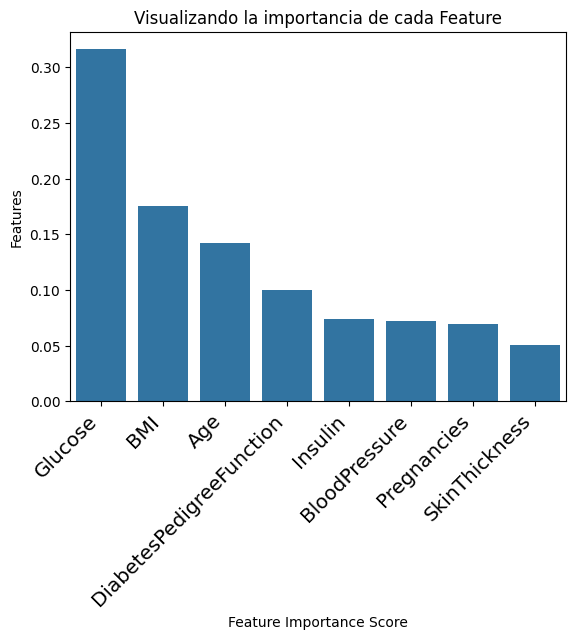

In [18]:
sns.barplot(x=feature_importances_df.feature,y=feature_importances_df.importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Visualizando la importancia de cada Feature')
plt.xticks(rotation=45,horizontalalignment ="right",fontweight="light",fontsize="x-large")
plt.show()